## Block 1: Dropping Columns That Shouldn't Reach the Model

Before encoding or scaling anything, we remove columns that are either:
- Redundant with a column we're keeping (raw diag codes vs. diag groups, _id vs. _desc pairs)
- Pure identifiers with no causal signal (patient_nbr)
- Direct sources of label leakage (the original 3-class `readmitted`)

We keep `patient_nbr` around one step longer — for the split only — then drop it right after.

In [1]:
# Load engineered data
import pandas as pd
import numpy as np

df = pd.read_csv('../data/diabetic_data_engineered.csv')
print("Starting shape:", df.shape)

# Columns to drop from modeling (patient_nbr dropped AFTER the split, not here)
cols_to_drop = [
    'readmitted',          # 3-class original -> label leakage, we use readmitted_binary
    'diag_1', 'diag_2', 'diag_3',   # superseded by diag_1_group/diag_2_group/diag_3_group
    'admission_type_id',            # keeping the _desc version instead
    'discharge_disposition_id',
    'admission_source_id',
]

df_model = df.drop(columns=cols_to_drop)
print("After drop:", df_model.shape)
print("the left features: ", df_model.columns.tolist())

Starting shape: (99343, 44)
After drop: (99343, 37)
the left features:  ['patient_nbr', 'race', 'gender', 'age', 'weight', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted_binary', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'admission_type_desc', 'discharge_disposition_desc', 'admission_source_desc', 'num_meds_changed', 'total_prior_visits', 'diabetes_related']


drop is correct. 44 → 37 columns, and the logic holds:

`readmitted` gone (leakage, you already have `readmitted_binary`)
`diag_1/2/3` gone (replaced by the `_group` versions)
`patient_nbr` kept for now, dropped right after split; good, that's the right order

`medical_specialty` and `payer_code` are still sitting in the list as raw columns (both high-missingness, formalized as "Missing") But im going to deal with it later. 

## Block 2: Patient-Level Train/Test Split

Our EDA found 69,990 unique patients across 99,343 encounters (avg 1.42 encounters/patient).
Because the same patient can appear more than once, a normal row-level `train_test_split`
would let the same patient leak into both train and test; the model could partly
"memorize" a patient instead of generalizing. So we split on `patient_nbr` first, then
pull the corresponding rows.

Steps:
1. Get the unique list of patient IDs.
2. Split *that list* into train/test patient IDs (stratifying isn't needed here; we're
   splitting IDs, not the target itself).
3. Filter the full dataframe rows by which set each patient's ID falls into.
4. Verify with a set-intersection check that no patient exists in both sets.
5. Only now do we drop `patient_nbr` — its job (grouping rows for the split) is done.

In [2]:
from sklearn.model_selection import train_test_split

# Step 1: unique patients
unique_patients = df_model['patient_nbr'].unique()
print("Unique patients:", len(unique_patients))

# Step 2: split the patient IDs (not the rows) 80/20
train_patients, test_patients = train_test_split(
    unique_patients, test_size=0.2, random_state=42
)
print("Train patients:", len(train_patients), " Test patients:", len(test_patients))

# Step 3: filter rows by patient membership
train_df = df_model[df_model['patient_nbr'].isin(train_patients)].copy()
test_df  = df_model[df_model['patient_nbr'].isin(test_patients)].copy()
print("Train rows:", train_df.shape, " Test rows:", test_df.shape)

# Step 4: leak check — this set must be empty
overlap = set(train_df['patient_nbr']) & set(test_df['patient_nbr'])
print("Patient overlap between train and test:", len(overlap))
assert len(overlap) == 0, "Leakage detected — a patient appears in both sets!"

# Step 5: drop patient_nbr now that its job is done
train_df = train_df.drop(columns=['patient_nbr'])
test_df  = test_df.drop(columns=['patient_nbr'])

print("\nFinal train shape:", train_df.shape)
print("Final test shape:", test_df.shape)
print("Train readmit rate: {:.2%}".format(train_df['readmitted_binary'].mean()))
print("Test readmit rate:  {:.2%}".format(test_df['readmitted_binary'].mean()))

Unique patients: 69990
Train patients: 55992  Test patients: 13998
Train rows: (79219, 37)  Test rows: (20124, 37)
Patient overlap between train and test: 0

Final train shape: (79219, 36)
Final test shape: (20124, 36)
Train readmit rate: 11.33%
Test readmit rate:  11.63%


#### some insights:
* 69,990 unique patients → split into 55,992 for train / 13,998 for test (that's your 80/20, applied to patients, not rows)

* That patient split pulled 79,219 rows into train / 20,124 rows into test — makes sense, since patients have ~1.4 encounters on average, so patient counts and row counts don't match exactly
* Patient overlap: 0 → your leakage check passed. No patient exists in both sets. This is the most important line in the output.

## Block 3: Encoding Categorical Columns

A cardinality check on the categorical columns shows one column needed a real decision
before encoding ; the rest are straightforward:

| Column | Unique values |
|---|---|
| `medical_specialty` | 73 (decision: dropped — see below) |
| `discharge_disposition_desc` | 20 |
| `payer_code` | 18 |
| `admission_source_desc` | 15 |
| `diag_1/2/3_group`, `race`, `age`, `weight`, etc. | ≤10 |
| medication columns, `change`, `diabetesMed`, `gender` | 2–4 |

**Decision: `medical_specialty` is dropped entirely, not bucketed.**

The initial plan was to bucket it into the top 10 most frequent specialties + an
"Other_specialty" catch-all, to avoid one-hot encoding all 73 raw values. But checking
which specialties actually make the top 10 revealed that Pediatrics-Endocrinology ,
the one specialty from EDA that showed a real, non-noise signal (357 rows, 5.3%
readmission vs. ~11% baseline) ; doesn't survive that cutoff. It would fold into
"Other_specialty" regardless. Since EDA already showed the raw column's other swings
(Internal Medicine, Cardiology, etc.) were mostly small-sample **noise** that flattens
toward baseline, bucketing would keep exactly the specialties with weak signal while
still discarding the one with real signal. That defeats the purpose of keeping the
column at all , so it's dropped outright.

(If the Pediatrics finding is worth preserving later, the way to do it is a
dedicated `is_pediatrics_specialty` binary flag ; not a frequency-based bucket. That's
a separate, smaller decision, not part of this pass.) -- It's still under construction -- 

Everything else at 20 or fewer categories gets standard one-hot encoding.



In [3]:
# --- Step 1: drop medical_specialty entirely ---
# Decision: EDA showed its raw signal is mostly small-sample noise, and the one real
# finding (Pediatrics-Endocrinology, 357 rows, 5.3% readmit) doesn't survive top-10
# bucketing anyway (it's the 16th most frequent specialty out of 73), so bucketing would
# only keep low-signal, high-volume specialties. Dropping is the consistent, evidence-based
# call given what Notebook 1 already found.

train_df = train_df.drop(columns=['medical_specialty'])
test_df  = test_df.drop(columns=['medical_specialty'])

print("Train shape after dropping medical_specialty:", train_df.shape)
print("Test shape after dropping medical_specialty:", test_df.shape)


print(train_df.columns.tolist())

# --- Step 2: identify all categorical (object/string) columns to encode ---
categorical_cols = train_df.select_dtypes(include=['object', 'string']).columns.tolist()
# readmitted_binary is numeric already (it's the target), so it won't show up here — confirm:
print("\nColumns to one-hot encode:", categorical_cols)

# --- Step 3: one-hot encode, fit categories on train, align test to match ---
train_encoded = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_encoded  = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

# Align test columns to train columns exactly (fills any missing dummy cols with 0)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

print("\nTrain shape after encoding:", train_encoded.shape)
print("Test shape after encoding:", test_encoded.shape)
assert list(train_encoded.columns) == list(test_encoded.columns), "Column mismatch after encoding!"

Train shape after dropping medical_specialty: (79219, 35)
Test shape after dropping medical_specialty: (20124, 35)
['race', 'gender', 'age', 'weight', 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted_binary', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'admission_type_desc', 'discharge_disposition_desc', 'admission_source_desc', 'num_meds_changed', 'total_prior_visits', 'diabetes_related']

Columns to one-hot encode: ['race', 'gender', 'age', 'weight', 'payer_code', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'adm

## Block 4: Scaling Numeric Columns

Only Logistic Regression needs scaling ; it's sensitive to feature magnitude because it
optimizes via gradient descent over a distance-based loss. Tree-based models (Decision
Tree, Random Forest, XGBoost) split on thresholds per feature independently, so scaling
doesn't change their behavior; we skip it for those.

**Fit-on-train-only rule applies again:** the scaler learns mean/std (or min/max) from
`train_encoded` only, then that same fitted transformation is applied to `test_encoded`.
Fitting on the combined data - or on test - would leak test-set distribution info into
training, inflating apparent performance.

We keep both a scaled and unscaled version of the data around: unscaled feeds the tree
models, scaled feeds Logistic Regression.

AS..
* Decision Tree / Random Forest / XGBoost / CatBoost all split on thresholds per feature independently (e.g., "is num_lab_procedures > 42?"). The threshold search doesn't care whether the feature ranges 0–1 or 0–1000 — same split, same result either way.
* Gaussian Naive Bayes estimates a separate mean/variance per feature, per class and multiplies per-feature likelihoods. It's not comparing distances across features, so scaling one feature relative to another doesn't change its output.

In [4]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
                'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses',
                'num_meds_changed', 'total_prior_visits']

# Separate features/target for clarity
X_train = train_encoded.drop(columns=['readmitted_binary'])
y_train = train_encoded['readmitted_binary']
X_test  = test_encoded.drop(columns=['readmitted_binary'])
y_test  = test_encoded['readmitted_binary']

# Fit scaler on train numeric columns only
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])  # transform only, no fit

print("Scaled numeric column means (train, should be ~0):")
print(X_train_scaled[numeric_cols].mean().round(3))
print("\nScaled numeric column means (test, will NOT be exactly 0 — that's expected):")
print(X_test_scaled[numeric_cols].mean().round(3))

Scaled numeric column means (train, should be ~0):
time_in_hospital      0.0
num_lab_procedures   -0.0
num_procedures        0.0
num_medications      -0.0
number_outpatient     0.0
number_emergency      0.0
number_inpatient      0.0
number_diagnoses      0.0
num_meds_changed      0.0
total_prior_visits    0.0
dtype: float64

Scaled numeric column means (test, will NOT be exactly 0 — that's expected):
time_in_hospital     -0.002
num_lab_procedures    0.013
num_procedures       -0.005
num_medications       0.003
number_outpatient     0.026
number_emergency      0.043
number_inpatient      0.029
number_diagnoses      0.014
num_meds_changed      0.005
total_prior_visits    0.047
dtype: float64


## Block 5: Handling Class Imbalance

Confirmed target imbalance from EDA: 11.39% positive class (<30-day readmission). Rather
than resampling the data (SMOTE, undersampling), we handle this at the model level via
class weighting ; this keeps the real data distribution intact and avoids the risk of
synthetic-sample artifacts or throwing away real majority-class information.

Per-model handling differs, since not every library exposes the same mechanism:

| Model | Mechanism |
|---|---|
| Logistic Regression | `class_weight='balanced'` |
| Decision Tree | `class_weight='balanced'` |
| Random Forest | `class_weight='balanced'` |
| XGBoost | `scale_pos_weight` (ratio, computed manually ; no `class_weight` param) |
| Gaussian Naive Bayes | **no equivalent parameter** ; flagged as a known limitation, not silently ignored |
| CatBoost/LightGBM | `class_weight='balanced'` (LightGBM) / `auto_class_weights='Balanced'` (CatBoost) |

We compute `scale_pos_weight` here so it's ready when we get to the XGBoost block later,
rather than recomputing it mid-training.

`A reminder about class waiting from the slides of the thirteenth session:` 

***Class weights***
Assigns a higher penalty for misclassifying the minority
class directly in the algorithm setup.
If the model guesses wrong on the rare class, the loss
function spikes significantly more than for a majority
error

In [5]:
# Confirm the imbalance matches EDA findings
readmit_rate = y_train.mean()
print(f"Train set positive class rate: {readmit_rate:.4f} ({readmit_rate:.2%})")

# scale_pos_weight for XGBoost = (# negative) / (# positive)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Negative class count: {neg_count}, Positive class count: {pos_count}")
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.3f}")

# Known limitation note — not a code fix, just documenting it here so it isn't forgotten later
print("\nNote: Gaussian Naive Bayes has no class_weight equivalent; "
      "this will be flagged during its evaluation as a known limitation, "
      "not silently glossed over.")

Train set positive class rate: 0.1133 (11.33%)
Negative class count: 70246, Positive class count: 8973
scale_pos_weight for XGBoost: 7.829

Note: Gaussian Naive Bayes has no class_weight equivalent; this will be flagged during its evaluation as a known limitation, not silently glossed over.


## Block 6: Training the 6 Models

Each model gets trained with its own imbalance-handling mechanism (established in Block 5),
and on the correct input ; scaled data for Logistic Regression, unscaled for everything else
(established in Block 4). We store fitted models, hard predictions, and predicted
probabilities together in one dictionary, since the probabilities are needed later for
ROC-AUC and threshold simulation, not just the hard 0/1 predictions.

Note on Gaussian Naive Bayes: no `class_weight` parameter exists for it. We train it as-is
and carry the limitation forward into evaluation rather than pretending it's been handled.

XGBoost being strict about column names, not the code being wrong. Here's what's happening.


Root cause: somewhere in the one-hot encoded columns, a column name contains [, ], or < characters. This almost certainly comes from your age column; if the original values look like [70-80) or similar bracketed ranges, one-hot encoding turns that into a column literally named something like age_[70-80). XGBoost's newer versions refuse to train if any feature name contains those specific characters, because they're reserved for its own internal syntax.

That's why the following cell is going to be run before the models' cell. 

In [6]:
import re

def clean_column_names(df):
    df = df.copy()
    df.columns = [re.sub(r'[\[\]<]', '', str(col)) for col in df.columns]
    return df

X_train = clean_column_names(X_train)
X_test = clean_column_names(X_test)
X_train_scaled = clean_column_names(X_train_scaled)
X_test_scaled = clean_column_names(X_test_scaled)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

models = {}
predictions = {}
probabilities = {}

# 1. Logistic Regression — uses SCALED data
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr
predictions['Logistic Regression'] = lr.predict(X_test_scaled)
probabilities['Logistic Regression'] = lr.predict_proba(X_test_scaled)[:, 1]

# 2. Gaussian Naive Bayes — no class_weight equivalent (known limitation)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
models['Gaussian Naive Bayes'] = gnb
predictions['Gaussian Naive Bayes'] = gnb.predict(X_test)
probabilities['Gaussian Naive Bayes'] = gnb.predict_proba(X_test)[:, 1]

# 3. Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
models['Decision Tree'] = dt
predictions['Decision Tree'] = dt.predict(X_test)
probabilities['Decision Tree'] = dt.predict_proba(X_test)[:, 1]

# 4. Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
predictions['Random Forest'] = rf.predict(X_test)
probabilities['Random Forest'] = rf.predict_proba(X_test)[:, 1]

# 5. XGBoost — scale_pos_weight computed in Block 5
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
models['XGBoost'] = xgb
predictions['XGBoost'] = xgb.predict(X_test)
probabilities['XGBoost'] = xgb.predict_proba(X_test)[:, 1]

# 6. CatBoost
cb = CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42)
cb.fit(X_train, y_train)
models['CatBoost'] = cb
predictions['CatBoost'] = cb.predict(X_test)
probabilities['CatBoost'] = cb.predict_proba(X_test)[:, 1]

print("All 6 models trained:", list(models.keys()))

All 6 models trained: ['Logistic Regression', 'Gaussian Naive Bayes', 'Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost']


## Block 7: Evaluation Metrics Table

Recall is prioritized over accuracy; a missed readmission (false negative) is more costly
than a false alarm, and with only 11.33% positive class, accuracy alone would be misleading
(a model predicting "no readmission" for everyone would still score ~89% accuracy while
being useless). We compute the full metric set for every model so the comparison is
complete, but recall is the metric we explicitly rank by.

* `Recall` = "of all patients who really got readmitted, how many did the model catch?" ; this is your priority metric.
* `Precision` = "of all patients the model flagged as high-risk, how many actually were?"
* `F1` = a single number that balances precision and recall.
* `ROC-AUC`= how well the model separates the two classes overall, across all possible thresholds, not just at 0.5.

In [8]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

results = []

for name, model in models.items():
    X_eval = X_test_scaled if name in ['Logistic Regression', 'Gaussian Naive Bayes'] else X_test
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    results.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values('Recall', ascending=False)
print("\n=== Summary (sorted by Recall) ===")
print(results_df.to_string(index=False))


--- Logistic Regression ---
[[12194  5589]
 [ 1108  1233]]

--- Gaussian Naive Bayes ---
[[  675 17108]
 [   70  2271]]

--- Decision Tree ---
[[15241  2542]
 [ 1901   440]]

--- Random Forest ---
[[17665   118]
 [ 2262    79]]

--- XGBoost ---
[[11528  6255]
 [ 1004  1337]]

--- CatBoost ---
[[12708  5075]
 [ 1180  1161]]

=== Summary (sorted by Recall) ===
               Model  Precision   Recall       F1  ROC-AUC
Gaussian Naive Bayes   0.117189 0.970098 0.209116 0.595636
             XGBoost   0.176106 0.571123 0.269204 0.644322
 Logistic Regression   0.180739 0.526698 0.269126 0.654692
            CatBoost   0.186177 0.495942 0.270724 0.646923
       Decision Tree   0.147552 0.187954 0.165320 0.522504
       Random Forest   0.401015 0.033746 0.062254 0.656637


#### what each number in the summary actually means, using GNB vs. Random Forest as your two extremes

##### Gaussian Naive Bayes: [[675, 17108], [70, 2271]]

* This model predicted "readmit" for almost everyone; look at how huge that top-right number (17,108) is. That's 17,108 patients it wrongly flagged as high-risk when they weren't.
* But because it flags nearly everyone, it also happens to catch almost every real readmission: 2,271 out of 2,341 real cases. That's why Recall = 0.97 (97%); it almost never misses a true case, simply because it rarely says "no" to anyone.
* The cost of that: Precision = 0.117 (11.7%); of everyone it flagged as high-risk, only 11.7% actually were. It's crying wolf constantly to make sure it never misses the real wolf.

##### Random Forest: [[17665, 118], [2262, 79]], the opposite failure mode

* It barely ever says "readmit" (only 118 + 79 = 197 total positive predictions out of 20,124 patients). It's extremely cautious/conservative.
* Because it rarely predicts positive, when it does, it's often right: Precision = 0.401 (40%) ; the best precision of all 6 models.
* But that caution means it misses almost everyone who actually gets readmitted: Recall = 0.034 (3.4%) ; the worst recall of all 6 models.

*So precision and recall are pulling in opposite directions, and each model sits somewhere:
*
* Precision answers: "When I say 'high risk,' how often am I right?"
* Recall answers: "Of everyone who's actually high risk, how many did I catch?"
* A model that flags everyone (like GNB) gets great recall, terrible precision. A model that flags almost no one (like Random Forest) gets great precision, terrible recall.

#### A proof justification of why we use the recall, not the accuracy metric using for example Random Forest row

Random Forest's accuracy (let me calculate it from its confusion matrix [[17665, 118], [2262, 79]]):

Total test patients: 20,124
Correct predictions: 17,665 (correctly said "no readmit") + 79 (correctly said "readmit") = 17,744
Accuracy = 17,744 / 20,124 = 88.2%

That looks fantastic on paper 88% accuracy! But look at recall: 3.3%. Out of all patients who actually got readmitted, Random Forest caught only 79 of them (2,262 + 79 = 2,341 total actual readmissions); it missed 2,262 out of 2,341, a 96.6% miss rate on the exact thing you're trying to predict.

##### **The justification: Because only 11.33% of patients are readmitted, a model can score high accuracy just by predicting 'no readmission' almost every time; Random Forest's 88% accuracy comes from being right about the majority who don't get readmitted, while missing 97% of the minority who actually do, which is the group this whole project exists to catch.**

## Block 8: Confusion Matrices

Numbers alone (precision/recall) can hide *which* errors a model makes. Confusion matrices
make the false-negative rate visible directly, since false negatives (missed readmissions)
are the costly error in this problem, seeing the raw counts matters more here than in a
balanced-cost scenario.

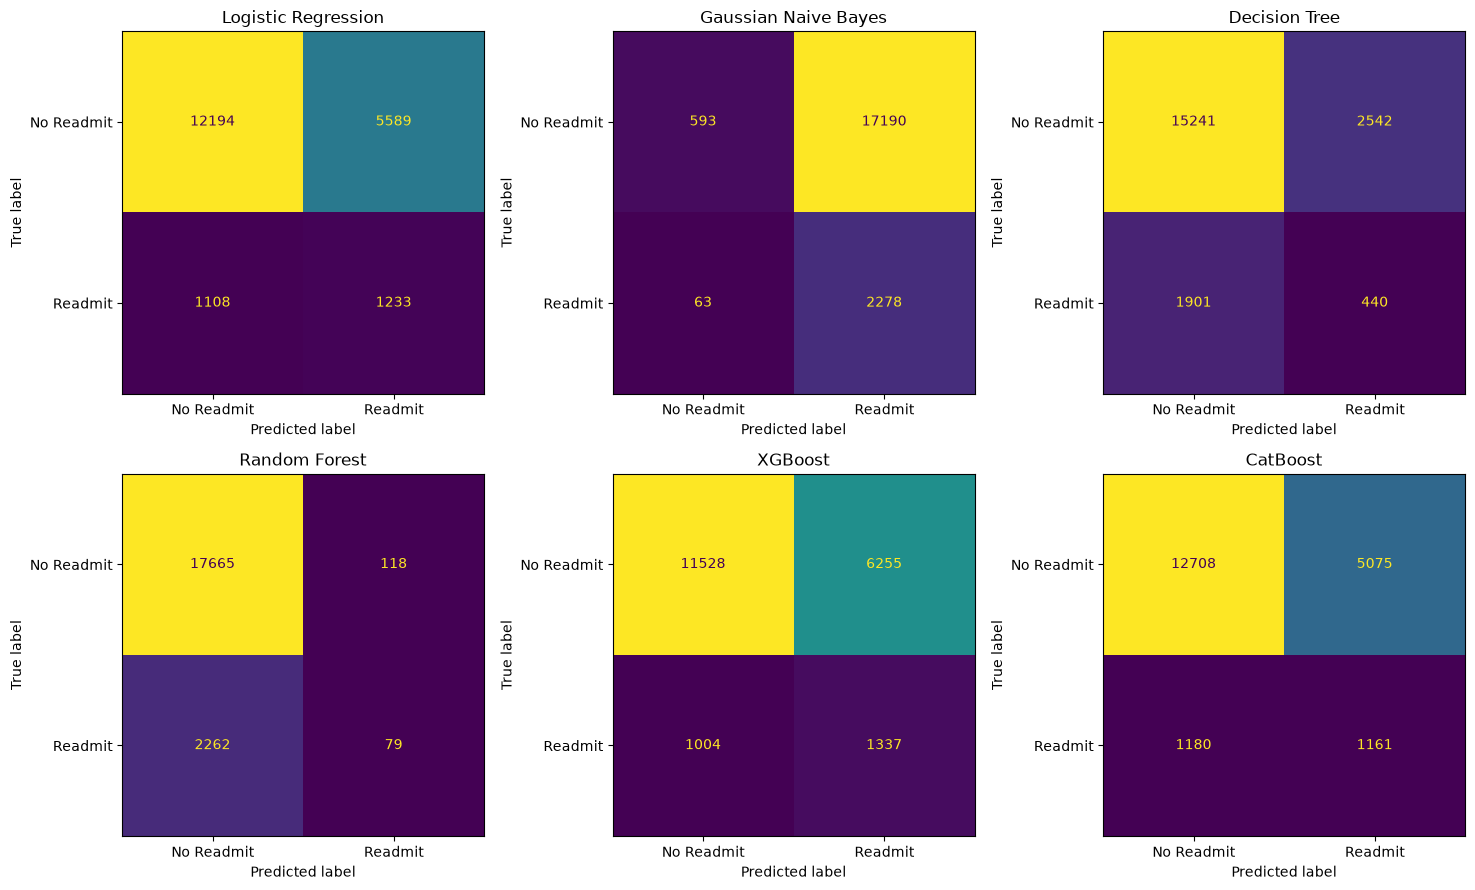

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, name in enumerate(models):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Readmit', 'Readmit'])
    disp.plot(ax=axes[idx], colorbar=False)
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

## Block 9: ROC Curve Comparison

A single overlay plot of all 6 ROC curves gives a visual, at-a-glance comparison that
complements the numeric ROC-AUC column from Block 7; useful for both your own analysis
and directly reusable in the presentation.

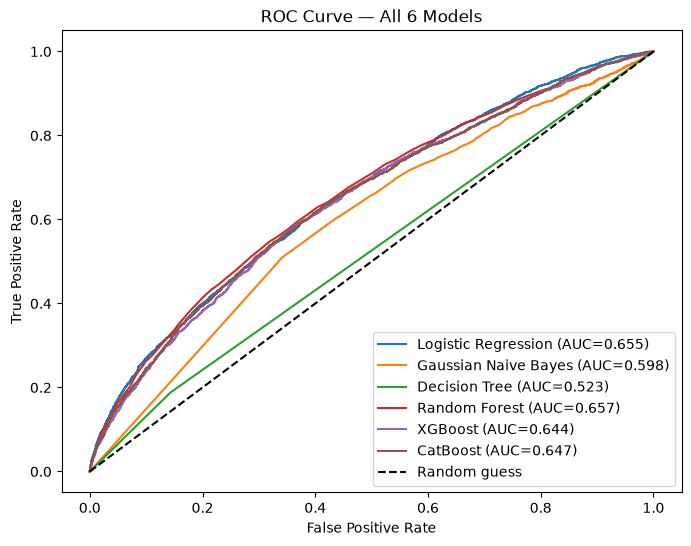

In [10]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_val = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All 6 Models')
plt.legend()
plt.show()

##### *Concept*: ROC-AUC (from Block 7) is a single number, but the ROC curve shows the **full tradeoff** a model makes between catching true positives and accidentally flagging false positives, at every possible decision threshold; not just 0.5.

##### What it does: Plots all 6 models' curves on one chart so you can visually compare which model dominates (sits higher/more top-left) across the board.

##### What it's related to: Uses the probabilities dictionary (not hard predictions); this only works because Block 6 stored probability scores, not just yes/no labels.

##### What it means: A model whose curve sits clearly above the others is separating the two classes better overall. 

## Block 10: Cost-Aware Model Ranking

Recall/F1/ROC-AUC treat all errors as equally weighted. In a real hospital setting they
aren't: missing a readmission (false negative) usually costs more than an unnecessary
intervention on a patient who wouldn't have been readmitted (false positive); think
follow-up calls or care coordination vs. an actual repeat hospital stay.

We assign illustrative cost values (these should be stated as assumptions, not real
hospital figures, unless you have sourced numbers) and compute total expected cost per
model. This can change the "winner" from Block 7's recall ranking; that's the point of
having a business layer at all.

In [11]:
# Illustrative costs — state clearly in your writeup that these are assumptions
COST_FALSE_NEGATIVE = 5000   # cost of a missed readmission (readmission penalty + care cost)
COST_FALSE_POSITIVE = 500    # cost of an unnecessary intervention (follow-up call, etc.)

cost_results = []
for name in models:
    cm = confusion_matrix(y_test, predictions[name])
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    cost_results.append({
        'Model': name,
        'False Negatives': fn,
        'False Positives': fp,
        'Total Estimated Cost': total_cost
    })

cost_df = pd.DataFrame(cost_results).sort_values('Total Estimated Cost').reset_index(drop=True)
print(cost_df)

                  Model  False Negatives  False Positives  \
0               XGBoost             1004             6255   
1   Logistic Regression             1108             5589   
2              CatBoost             1180             5075   
3  Gaussian Naive Bayes               63            17190   
4         Decision Tree             1901             2542   
5         Random Forest             2262              118   

   Total Estimated Cost  
0               8147500  
1               8334500  
2               8437500  
3               8910000  
4              10776000  
5              11369000  


## Block 11: Threshold Simulation

Every model above used the default 0.5 classification threshold. That default isn't
necessarily cost-optimal, since false negatives are assumed more expensive (Block 10),
lowering the threshold (flagging more patients as high-risk) may reduce total cost even
though it increases false positives. We sweep thresholds for your best model (by Block 10's
cost ranking) and plot cost against threshold to find the actual minimum.

Best model by cost: XGBoost
    Threshold  Total Cost    FN     FP
0        0.05     8871500     8  17663
1        0.10     8783000    22  17346
2        0.15     8629000    43  16828
3        0.20     8438500    80  16077
4        0.25     8336500   171  14963
5        0.30     8212500   295  13475
6        0.35     8135500   456  11711
7        0.40     7925000   610   9750
8        0.45     8049500   816   7939
9        0.50     8147500  1004   6255
10       0.55     8598500  1242   4777
11       0.60     9059000  1466   3458
12       0.65     9514000  1680   2228
13       0.70    10175000  1911   1240
14       0.75    10662000  2068    644
15       0.80    11073000  2183    316
16       0.85    11338000  2255    126
17       0.90    11594500  2316     29


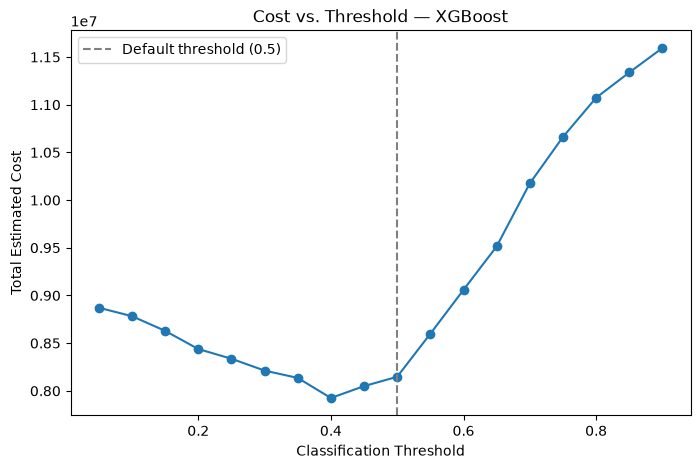


Cost-optimal threshold: 0.4


In [12]:
best_model_name = cost_df.iloc[0]['Model']
print("Best model by cost:", best_model_name)

thresholds = np.arange(0.05, 0.95, 0.05)
threshold_costs = []

for t in thresholds:
    y_pred_t = (probabilities[best_model_name] >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    threshold_costs.append({'Threshold': t, 'Total Cost': total_cost,
                             'FN': fn, 'FP': fp})

threshold_df = pd.DataFrame(threshold_costs)
print(threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df['Threshold'], threshold_df['Total Cost'], marker='o')
plt.xlabel('Classification Threshold')
plt.ylabel('Total Estimated Cost')
plt.title(f'Cost vs. Threshold — {best_model_name}')
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.legend()
plt.show()

best_threshold = threshold_df.loc[threshold_df['Total Cost'].idxmin(), 'Threshold']
print(f"\nCost-optimal threshold: {best_threshold}")

## Block 12: Persisting the Best Model

Before building an API, the trained model needs to be saved to disk so FastAPI can load
it without retraining every time the server starts. We save the model plus anything
needed to preprocess a new incoming patient the same way training data was preprocessed
(the scaler, and the exact column list after encoding).

In [13]:
import joblib

# Pick whichever model you're deploying — e.g. XGBoost, or your Block 10 cost-winner
best_deploy_model = models['XGBoost']

joblib.dump(best_deploy_model, '../app/model.pkl')
joblib.dump(scaler, '../app/scaler.pkl')
joblib.dump(list(X_train.columns), '../app/model_columns.pkl')

print("Saved model, scaler, and column list to /app")

Saved model, scaler, and column list to /app
